In [1]:
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA

import gym_linearnavigation

from sf import analysis
from sf.utils import run_model

torch.manual_seed(0)

/code/src/sf/analysis.py:15: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## Run the model

In [2]:
model_path = analysis.get_exemplar_model()
run = run_model(model_path, n_frames=5_000)[0]
print(f'Model: {model_path.name}')
print(f'Mean reward: {run.reward_avg:.1f}')

/usr/local/lib/python3.10/dist-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Model: w64_repro_seed__0_pre
Mean reward: 99.6


## Recurrent connectivity

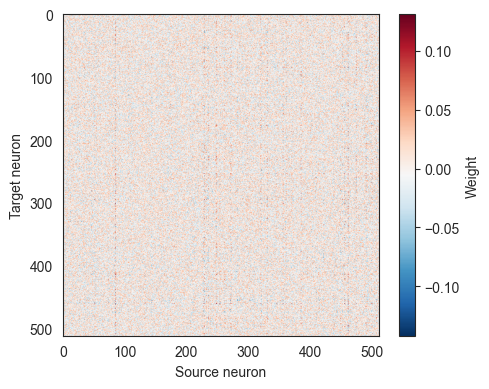

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(run.rnn.weight_hh_l0.detach().cpu(), cmap='RdBu_r', aspect='auto')
ax.set(xlabel='Source neuron', ylabel='Target neuron')
fig.colorbar(image, ax=ax, label='Weight')
fig.tight_layout()

## Stopping behaviour

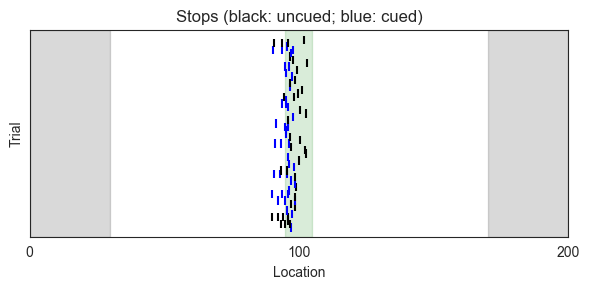

In [4]:
plt.figure(figsize=(6, 3))
analysis.plot_stops(run, minimal=False)
plt.title('Stops (black: uncued; blue: cued)')
plt.tight_layout()

## PCA activity manifold

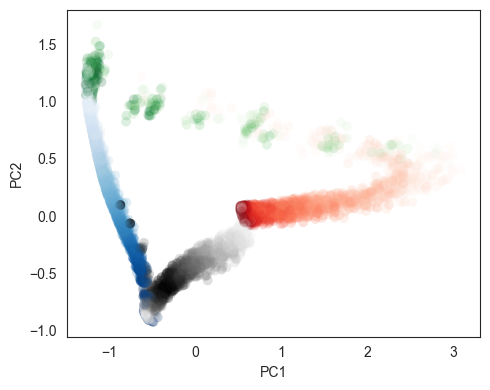

In [5]:
pca = PCA(n_components=2).fit(run.states)
plt.figure(figsize=(5, 4))
analysis.plot_pca_mpl_2d(run, pca=pca, alpha=0.2)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()